# El paquete `seaborn`

Seaborn es un paquete para realizar gráficos en Pyhton. Está construido *encima* de matplotlib y se integra muy bien con las estructuras del paquete `pandas`. Sus funciones operan en dataframes. 

Importamos los paquetes necesarios:

In [1]:
import pandas as pd
import random
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sns.set_theme() # tema por fefecto

In [2]:
tips = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/tips.csv")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Gráficas relacionales con facetas

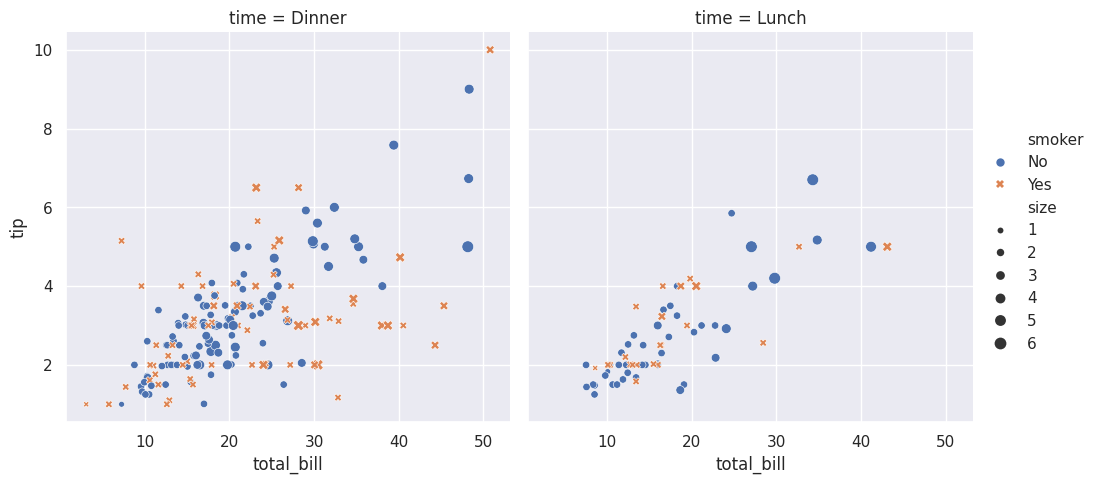

In [3]:
sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

## Histogramas

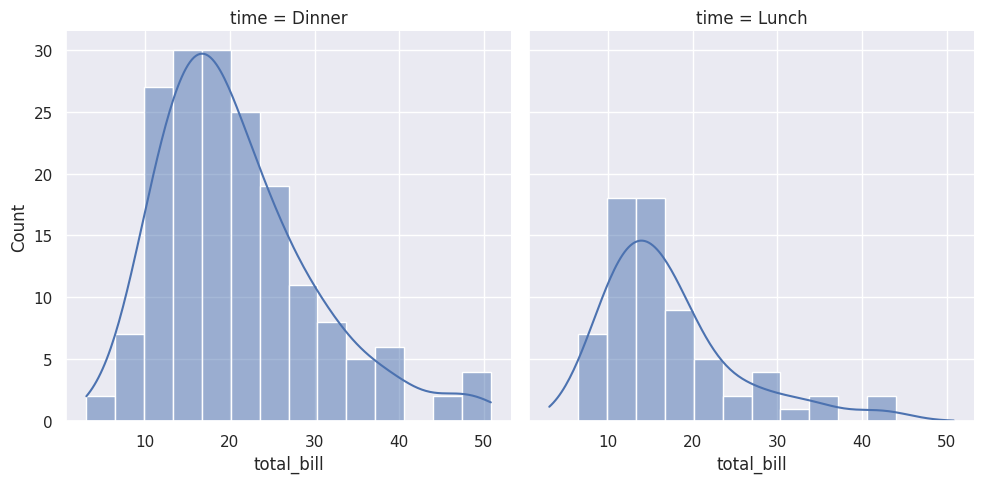

In [4]:
sns.displot(data=tips, x="total_bill", col="time", kde=True)

## Diagramas de caja y bigotes

<Axes: xlabel='day', ylabel='total_bill'>

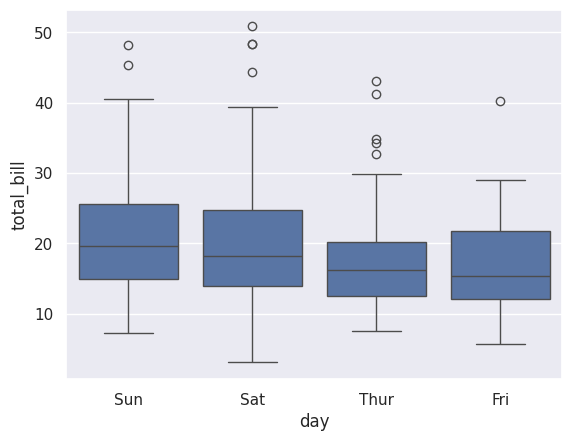

In [5]:
sns.boxplot(x = 'day', y = 'total_bill', data = tips) 

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

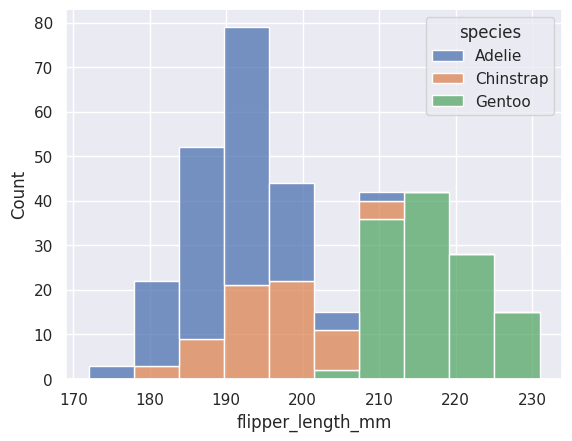

In [6]:
penguins = sns.load_dataset("penguins")
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")

## Gráficos conjuntos

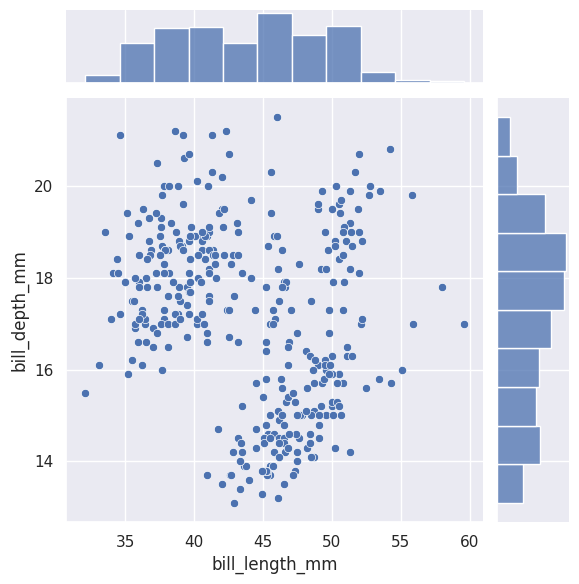

In [7]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")

## Parejas de variables de un dataframe

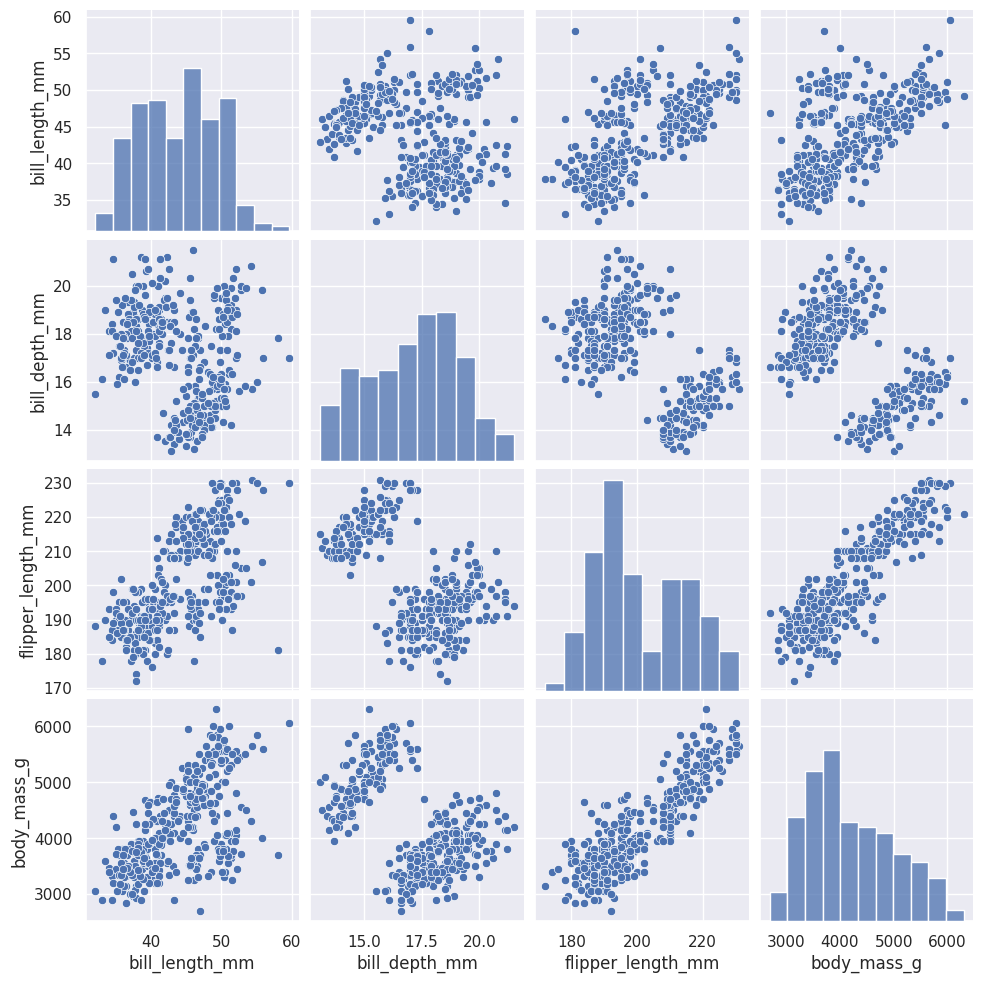

In [8]:
sns.pairplot(penguins)

In [9]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Gráfico de línea

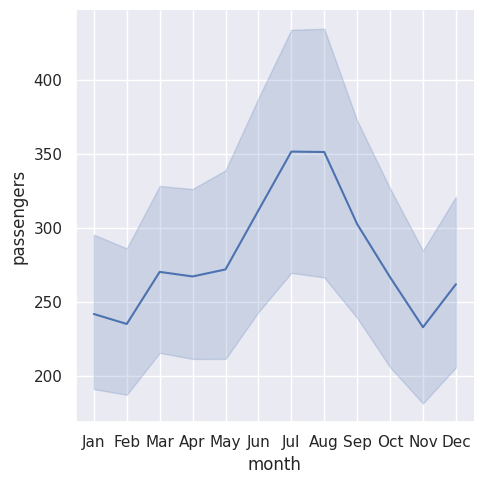

In [10]:
sns.relplot(data=flights, x="month", y="passengers", kind="line")

## Otro ejemplo

   Age  Salary  Experience
0   25   30000           2
1   30   35000           5
2   35   40000           7
3   40   45000          10
4   45   50000          12


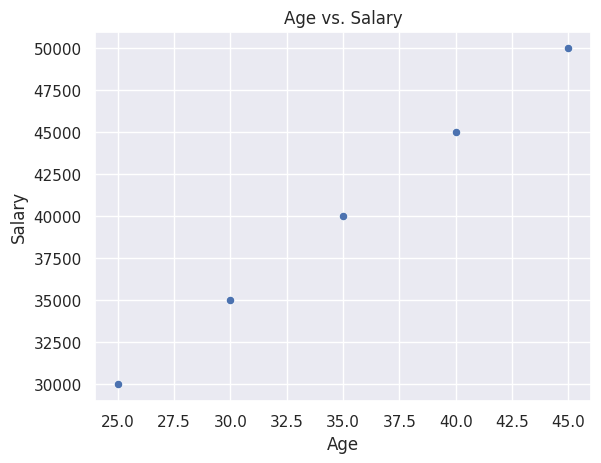

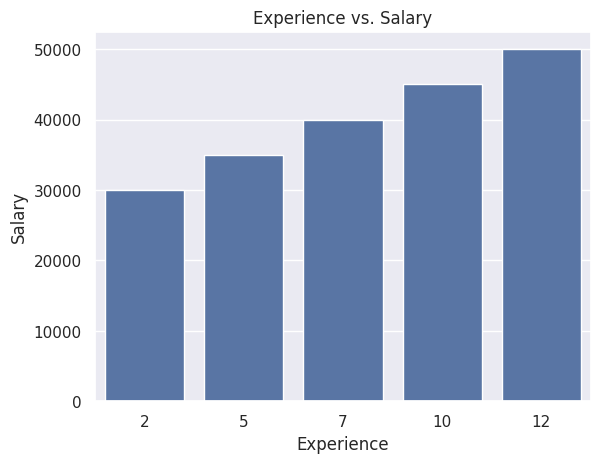

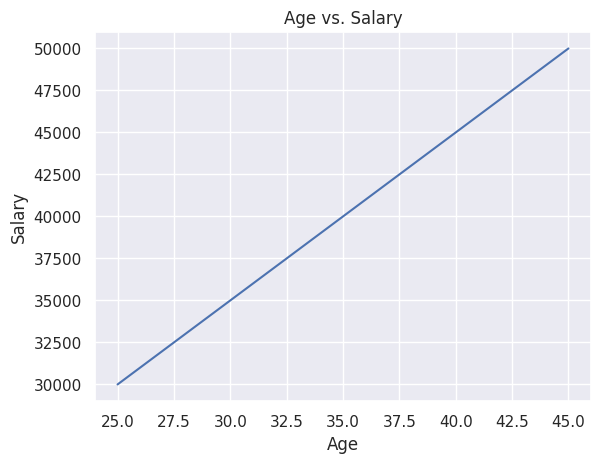

In [11]:
data = {'Age': [25, 30, 35, 40, 45],
        'Salary': [30000, 35000, 40000, 45000, 50000],
        'Experience': [2, 5, 7, 10, 12]}
df = pd.DataFrame(data)

print(df)


sns.scatterplot(x='Age', y='Salary', data=df)
plt.title('Age vs. Salary')
plt.show()


sns.barplot(x='Experience', y='Salary', data=df)
plt.title('Experience vs. Salary')
plt.show()


sns.lineplot(x='Age', y='Salary', data=df)
plt.title('Age vs. Salary')
plt.show()

# Titanic

In [12]:
titanic = sns.load_dataset("titanic")
titanic.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
231,0,3,male,29.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
66,1,2,female,29.0,0,0,10.5000,S,Second,woman,False,F,Southampton,yes,True
311,1,1,female,18.0,2,2,262.3750,C,First,woman,False,B,Cherbourg,yes,False
840,0,3,male,20.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
318,1,1,female,31.0,0,2,164.8667,S,First,woman,False,C,Southampton,yes,False


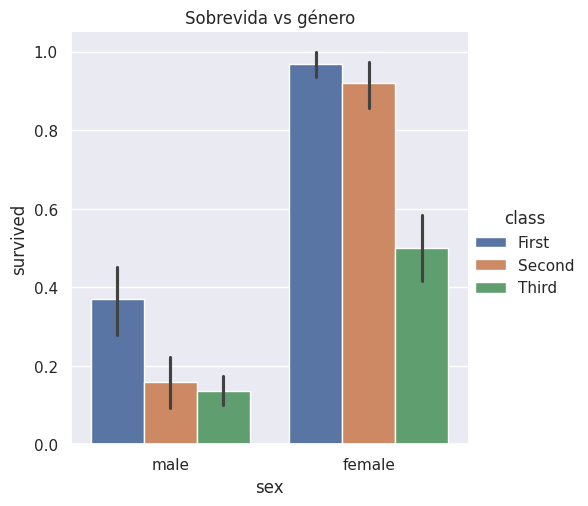

In [13]:
titanic = sns.load_dataset("titanic")
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="bar").set(title="Sobrevida vs género")

## Algo más elaborado

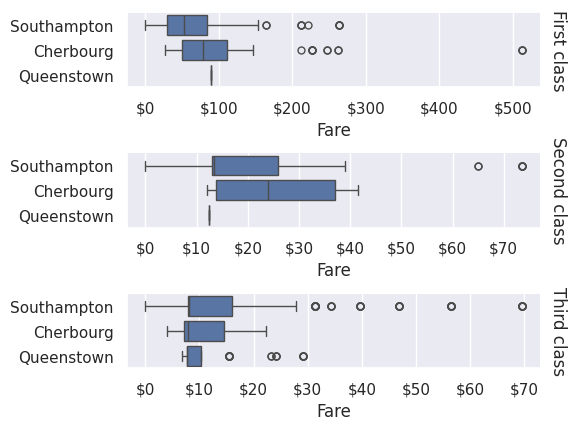

In [14]:
g = sns.catplot(
    data=titanic,
    x="fare", y="embark_town", row="class",
    kind="box", orient="h",
    sharex=False, margin_titles=True,
    height=1.5, aspect=4,
)
g.set(xlabel="Fare", ylabel="")
g.set_titles(row_template="{row_name} class")
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter('${x:.0f}')

## Gráfico de barras (Variables categóricas)

<Axes: >

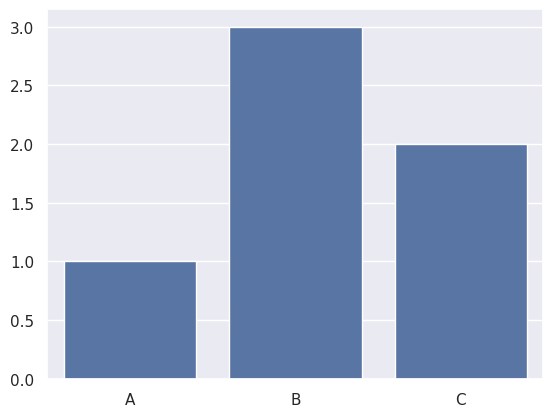

In [15]:
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

## Boxplot

<Axes: >

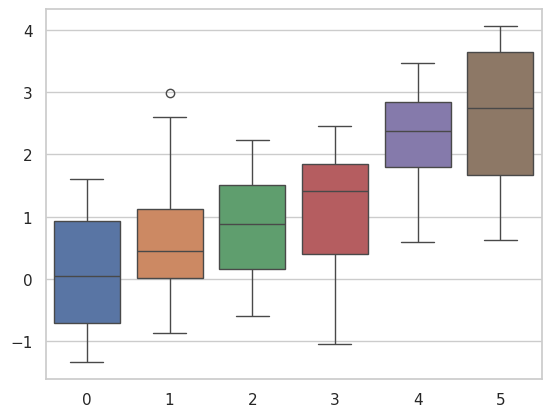

In [16]:
sns.set_style("whitegrid")
data = np.random.normal(size=(20, 6)) + np.arange(6) / 2
sns.boxplot(data=data)

Hay cinco temas (themes) para seaborn: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks`, el defecto es `darkgrid`.

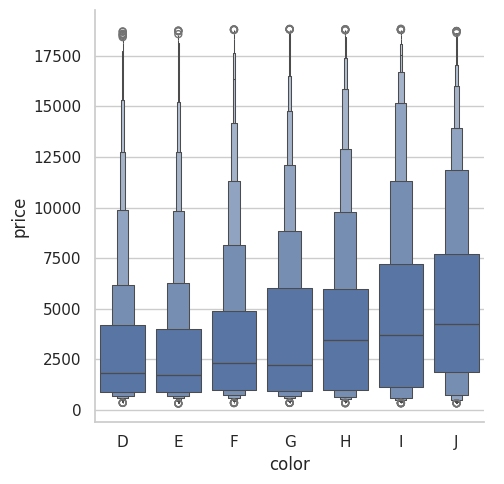

In [17]:
diamonds = sns.load_dataset("diamonds")
sns.catplot(
    data=diamonds.sort_values("color"),
    x="color", y="price", kind="boxen",
)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


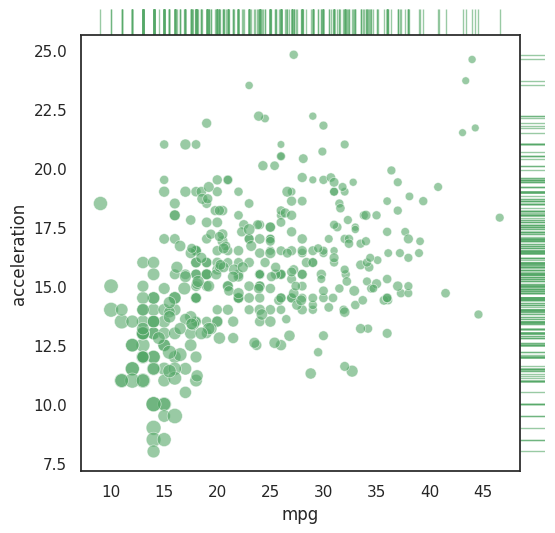

In [18]:
sns.set_theme(style="white", color_codes=True)
mpg = sns.load_dataset("mpg")

g = sns.JointGrid(data=mpg, x="mpg", y="acceleration", space=0, ratio=17)
g.plot_joint(sns.scatterplot, size=mpg["horsepower"], sizes=(30, 120),
             color="g", alpha=.6, legend=False)
g.plot_marginals(sns.rugplot, height=1, color="g", alpha=.6)